# COS60008 Introduction to data science
## Assignment 3 - Final Project, 2023, Semester 1
## Student Details: 
* Name: Kritika.
* Student id: 104361002
* Email: mailto:104361002@student.swin.edu.au
* Submission date: 28/06/2023
* Tutelab class: 3:30 - 5:30pm Thursday

## Task 2: Data exploration

In [1]:
#importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#importing the file we are working on
clean_data = pd.read_csv('clean_data.csv')
clean_data.describe()

,Year,Avg Min Temp °C,Yr Rain mm,Yield
count,120.000000,54.000000,120.000000,120.000000
mean,1999.500000,21.777778,1238.858083,1297.180583
std,11.591797,1.295226,368.408254,316.896985
min,1980.000000,19.900000,576.640000,768.500000
25%,1989.750000,20.800000,929.437500,1032.040000
50%,1999.500000,21.450000,1209.740000,1364.150000
75%,2009.250000,23.100000,1535.847500,1493.205000
max,2019.000000,24.000000,2067.680000,1774.110000


### What is the “Year” range (max, min) of the data collected?

In [3]:
clean_data.describe()
#min : 1980
#max : 2019

,Year,Avg Min Temp °C,Yr Rain mm,Yield
count,120.000000,54.000000,120.000000,120.000000
mean,1999.500000,21.777778,1238.858083,1297.180583
std,11.591797,1.295226,368.408254,316.896985
min,1980.000000,19.900000,576.640000,768.500000
25%,1989.750000,20.800000,929.437500,1032.040000
50%,1999.500000,21.450000,1209.740000,1364.150000
75%,2009.250000,23.100000,1535.847500,1493.205000
max,2019.000000,24.000000,2067.680000,1774.110000


### Are there any missing years in the data? If so, which?

In [4]:
unique_years = clean_data['Year'].unique()

# get the range of years
years_range = range(unique_years.min(), unique_years.max() + 1)

# Find the missing years
missing_years = set(years_range).difference(unique_years)

if missing_years:
    print("Missing years in the datafile are:")
    for year in missing_years:
        print(year)
else:
    print("No missing years in the datafile.")

No missing years in the datafile.


### What are the “Locations” (values) in the data?

In [5]:
#getting unique locations
unique_locations = clean_data['Location'].unique()
print(unique_locations)

['East Carlburgh' 'Ramirezview' 'East Carloston']


### What are the “Crop Types” (values) in the data?

In [6]:
#getting unique crop types
unique_crop_types = clean_data['Crop Type'].unique()
print(unique_crop_types)


['Canola' 'Wheat' 'Maize']


### What is the range (min, max) of the temperature values?
### What is the range (min, max) of the rainfall values?

In [7]:

clean_data.describe()
#this gives us minimum and maximum temperature values

,Year,Avg Min Temp °C,Yr Rain mm,Yield
count,120.000000,54.000000,120.000000,120.000000
mean,1999.500000,21.777778,1238.858083,1297.180583
std,11.591797,1.295226,368.408254,316.896985
min,1980.000000,19.900000,576.640000,768.500000
25%,1989.750000,20.800000,929.437500,1032.040000
50%,1999.500000,21.450000,1209.740000,1364.150000
75%,2009.250000,23.100000,1535.847500,1493.205000
max,2019.000000,24.000000,2067.680000,1774.110000


### Have all locations been used every year of data collection?

In [8]:
#get unique locations
unique_locations = clean_data['Location'].unique()
missing_years = []

for year in clean_data['Year'].unique():
    year_locations = clean_data[clean_data['Year'] == year]['Location'].unique()
    
    if len(year_locations) != len(unique_locations):
        missing_years.append(year)

if len(missing_years) > 0:
    print("The following years have missing locations:")
    for year in missing_years:
        print(year)
else:
    print("All locations have been used every year.")

All locations have been used every year.


### Do locations always have the same “Irrigated” value or does it change over the years?

In [9]:
#getting count of changes using nunique
location_irrigation_changes = clean_data.groupby('Location')['Irrigation'].nunique()
#we will get the number of changes
if len(location_irrigation_changes) == 1:
    print("Value remains the same for all locations.")
else:
    print("Value changes over the years for some locations.")
    print("Count of locations with changing value:", len(location_irrigation_changes))
#we can see all values change as we have three of them

Value changes over the years for some locations.
Count of locations with changing value: 3


### What is the total number of valid data entries (rows of data) you are expecting based on years of data collected and number of site locations? Is this the number you actually have? If not, why?

In [10]:
years = clean_data['Year'].unique()
locations = clean_data['Location'].unique()

expected_entries = len(years) * len(locations)
actual_entries = len(clean_data)

print("Expected number of data entries:", expected_entries)
print("Actual number of data entries:", actual_entries)

if actual_entries < expected_entries:
    missing_entries = expected_entries - actual_entries
    print("There are ", missing_entries, " missing data entries.")
elif actual_entries > expected_entries:
    excess_entries = actual_entries - expected_entries
    print("There are ", excess_entries, " excess data entries.")
else:
    print("The number of data entries matches the expected number.")


Expected number of data entries: 120
Actual number of data entries: 120
The number of data entries matches the expected number.


### What is the total occurrence (count used) of each crop type in the sample? (Table?)

In [11]:
crop_count = clean_data['Crop Type'].value_counts()
print(crop_count)

Maize     43
Canola    39
Wheat     38
Name: Crop Type, dtype: int64


### What is the break-down (count used) of “crop type” at each location? (Plot? Table?)

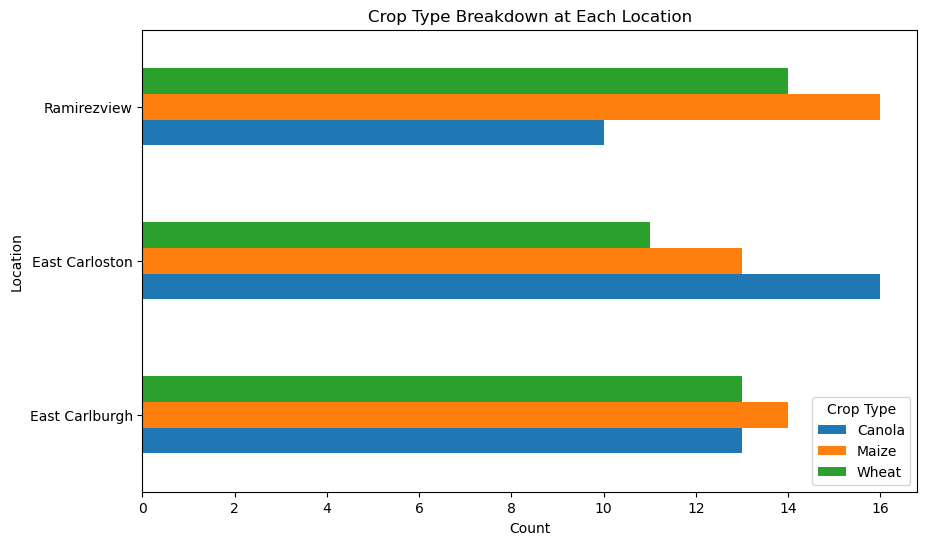

In [12]:
# Group data by location and crop type using groupby
location_crop_breakdown = clean_data.groupby(['Location', 'Crop Type']).size().unstack()
location_crop_breakdown.plot(kind='barh', figsize=(10, 6))
plt.xlabel('Count')
plt.ylabel('Location')
plt.title('Crop Type Breakdown at Each Location')
plt.legend(title='Crop Type')
plt.show()


### What is the total yield for each crop type over the entire sample? (Yield total by type?)

Crop Type
Canola    35505.37
Maize     57643.72
Wheat     62512.58
Name: Yield, dtype: float64


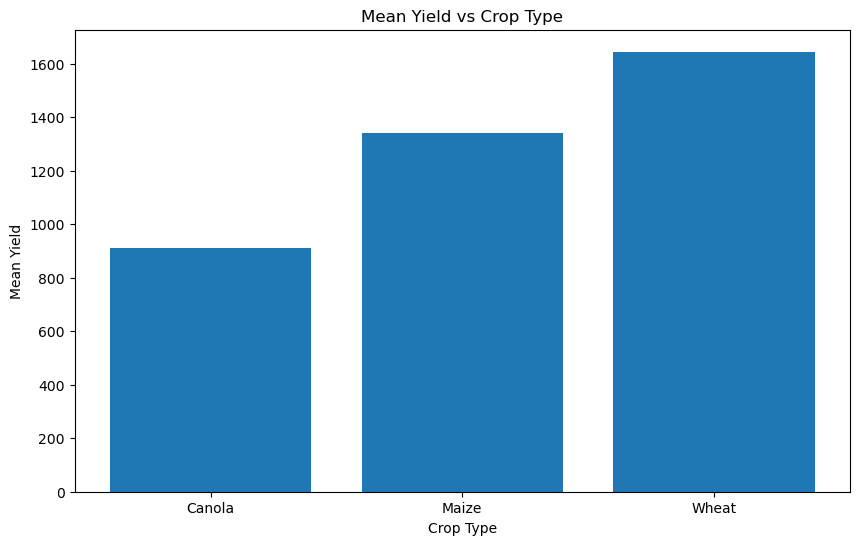

In [13]:
#grouping the data
crop_yield_total = clean_data.groupby('Crop Type')['Yield'].sum()
print(crop_yield_total)
#the mean yield is calculated and a graph was plotted between mean yield and crop type
mean_yield = clean_data.groupby("Crop Type")["Yield"].mean()

# Plotting the yield vs crop type
plt.figure(figsize=(10, 6))
plt.bar(mean_yield.index, mean_yield)
plt.xlabel("Crop Type")
plt.ylabel("Mean Yield")
plt.title("Mean Yield vs Crop Type")
plt.show()

### Has there been any changes in crop type usage over time? (Trends? Uniform? Plot?)

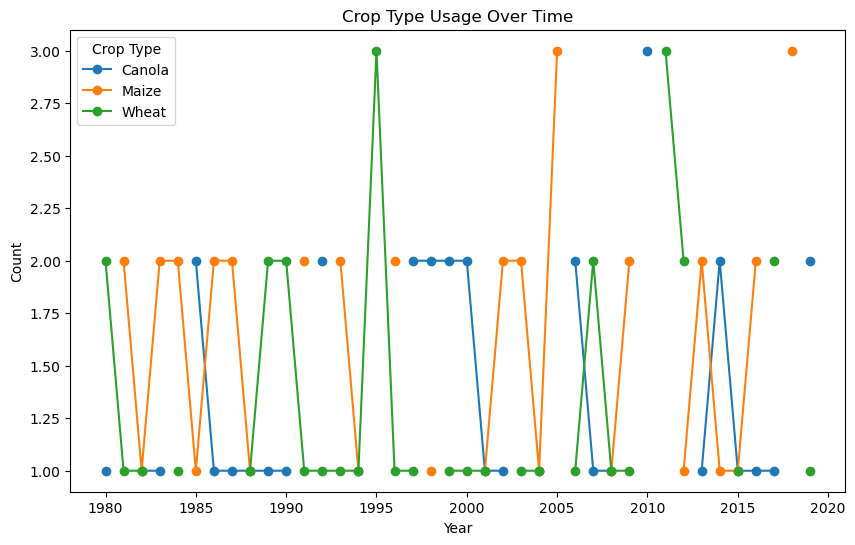

In [14]:

# Group the data by year and crop type, and calculate the count of each crop type
crop_type_usage = clean_data.groupby(['Year', 'Crop Type']).size().unstack()

# a line graph is plotted
fig, ax = plt.subplots(figsize=(10, 6))
crop_type_usage.plot(ax=ax, marker='o')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Crop Type Usage Over Time')
ax.legend(title='Crop Type')
plt.show()




### Staff members making obversions: Who was the longest serving staff member(s) making observations? How many years and at what location?

In [15]:

# using groupby to group the data by observer and calculate the duration of service
observer_service = clean_data.groupby('Observer')['Year'].nunique()

# finding observer with the longest duration of service
max_service_duration = observer_service.max()
longest_serving_observers = observer_service[observer_service == max_service_duration].index.tolist()

print("Longest Serving Observer:")
for observer in longest_serving_observers:
    years_of_service = max_service_duration
    location = clean_data.loc[clean_data['Observer'] == observer, 'Location'].unique()
    print(f"Observer: {observer}, Years of Service: {years_of_service}, Location: {location}")






Longest Serving Observer:
Observer: Samantha Parker, Years of Service: 8, Location: ['East Carlburgh']


### Did any staff member join again after they first performed the role?


In [16]:
#checking observers who joined again-
#grouping the data by observer and year and see the duplication of the data
observer_years = clean_data[['Observer', 'Year']].groupby('Observer')['Year'].unique()
observer_duplicates = observer_years[observer_years.apply(lambda x: len(x) > 1)]

if len(observer_duplicates) > 0:
    print("Observers who joined again:")
    for observer, years in observer_duplicates.items():
        print("Observer:", observer)
        print("Years:", years)
else:
    print("No observer joined again.")


Observers who joined again:
Observer: Amanda Sanchez
Years: [2002 2003 2004 2005]
Observer: Anthony Blackburn
Years: [1998 1999 2000 2001 2002 2003 2004]
Observer: Ashley Lopez
Years: [2017 2018]
Observer: David Rodriguez
Years: [1989 1990 1991 1992]
Observer: Derek King
Years: [1980 1981 1982]
Observer: Emily Johnson
Years: [1996 1997]
Observer: Erin Ramirez
Years: [1986 1987 1988]
Observer: Janet Galloway
Years: [1993 1994]
Observer: Joanna Palmer
Years: [1987 1988]
Observer: John Meyer
Years: [2015 2016]
Observer: John Young
Years: [1991 1992]
Observer: Justin Gibbs
Years: [2007 2008]
Observer: Kelly Thomas
Years: [1998 1999 2000]
Observer: Laura Lewis
Years: [1997 1998 1999]
Observer: Lee Gutierrez
Years: [2009 2010 2011 2012 2013 2014]
Observer: Linda Anderson
Years: [1982 1983 1984 1985]
Observer: Lindsay Jennings
Years: [2014 2015]
Observer: Martin Richards
Years: [1992 1993 1994 1995]
Observer: Michelle Garcia MD
Years: [1984 1985 1986 1987 1988 1989 1990]
Observer: Michelle Pe

In [17]:
###baseline questions answered moving on to another set of questions-

### Is there a relationship between temperature and yield? Is there a different between the irrigated and non-irrigated crops?


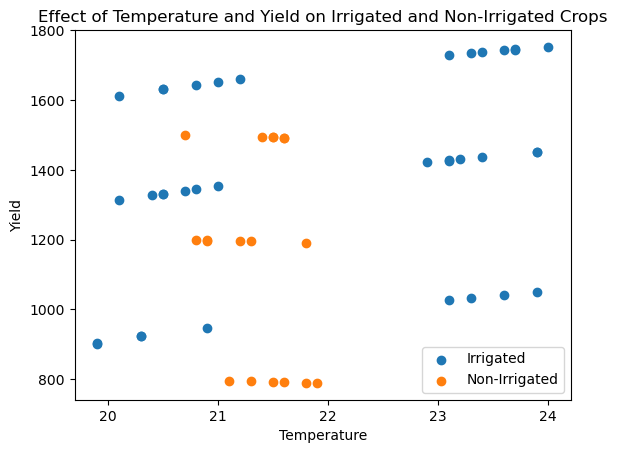

In [18]:

# Dividing crops into irrigated and non-irrigated crops
irrigated_crops = clean_data[clean_data['Irrigation'] == 'Y']
non_irrigated_crops = clean_data[clean_data['Irrigation'] == 'N']

# Create a scatter plot for temperature vs yield for both types of crops
plt.scatter(irrigated_crops['Avg Min Temp °C'], irrigated_crops['Yield'], label='Irrigated')
plt.scatter(non_irrigated_crops['Avg Min Temp °C'], non_irrigated_crops['Yield'], label='Non-Irrigated')

plt.xlabel('Temperature')
plt.ylabel('Yield')
plt.title('Effect of Temperature and Yield on Irrigated and Non-Irrigated Crops')
plt.legend(loc='lower right')
plt.show()
#crop types can also effect the above

### Is there a relationship between rainfall and yield? Is there a different between the irrigated and non-irrigated crops?


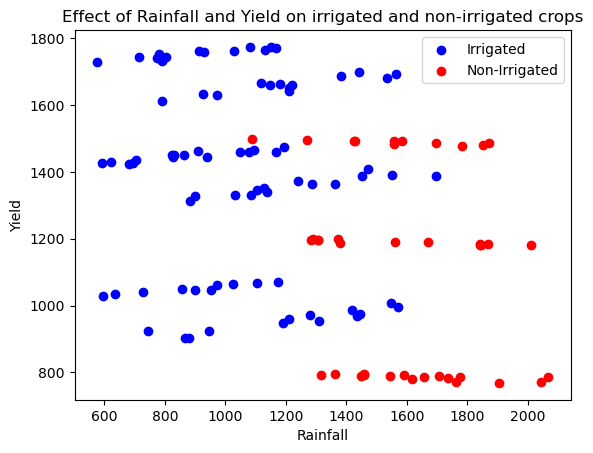

In [19]:
# dividing crops by irrigated and non-irrigated
irrigated_data = clean_data[clean_data['Irrigation'] == 'Y']
non_irrigated_data = clean_data[clean_data['Irrigation'] == 'N']

#irrigated crops
plt.scatter(irrigated_data['Yr Rain mm'], irrigated_data['Yield'], label='Irrigated', color='blue')
# non-irrigated crops
plt.scatter(non_irrigated_data['Yr Rain mm'], non_irrigated_data['Yield'], label='Non-Irrigated', color='red')

plt.xlabel('Rainfall')
plt.ylabel('Yield')
plt.title('Effect of Rainfall and Yield on irrigated and non-irrigated crops')

plt.legend()
plt.show()

### Is there a difference in yield trends (over time) at different locations?

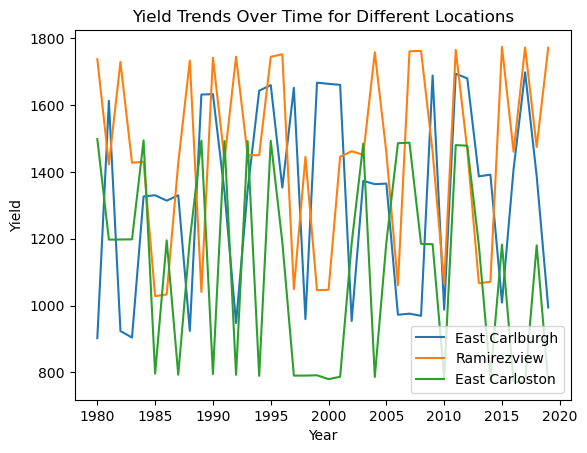

In [20]:
# subset the data for specific columns
yield_location_data = clean_data[['Year', 'Yield', 'Location']]

# getting all the unique locations
locations = yield_location_data['Location'].unique()

# Create line plots for each location
for location in locations:
    location_data = yield_location_data[yield_location_data['Location'] == location]
    plt.plot(location_data['Year'], location_data['Yield'], label=location)

plt.title('Yield Trends Over Time for Different Locations')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.legend()
plt.show()

### Show appropriate plots of Dry Spell and Heat Wave events to determine: Which locations have had the most and least events, respectively? Is there a relationship to temperature, rainfall, yield or year?

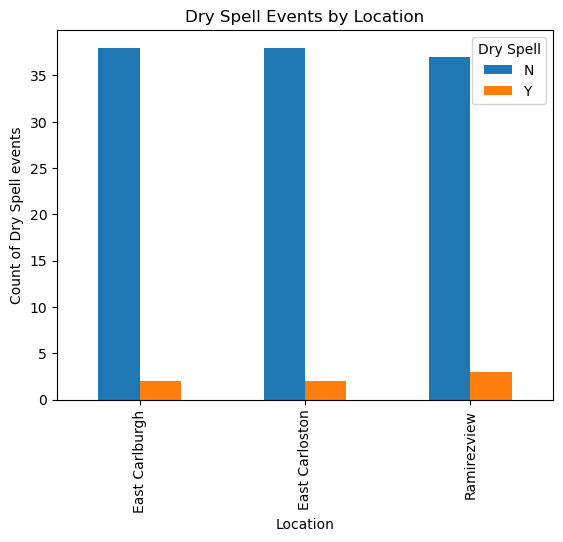

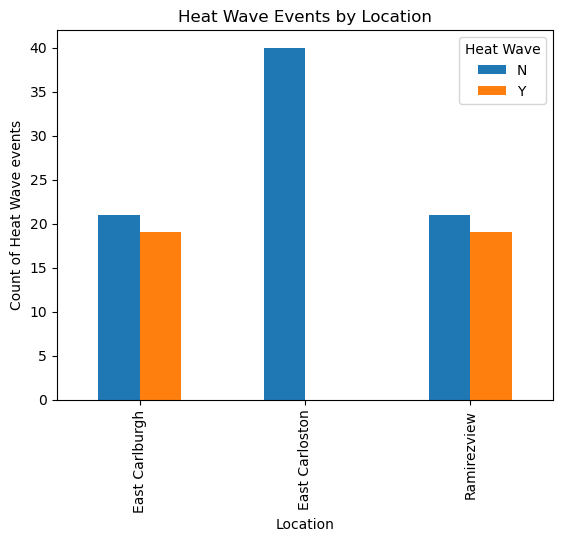

In [21]:
# grouping the data by Location and Dry Spell events
dry_spell_counts = clean_data.groupby('Location')['Dry Spell'].value_counts().unstack()

dry_spell_counts.plot(kind='bar')
plt.xlabel('Location')
plt.ylabel('Count of Dry Spell events')
plt.title('Dry Spell Events by Location')
plt.show()

# grouping the data by Location and Heat Wave events
heat_wave_counts = clean_data.groupby('Location')['Heat Wave'].value_counts().unstack()

heat_wave_counts.plot(kind='bar')
plt.xlabel('Location')
plt.ylabel('Count of Heat Wave events')
plt.title('Heat Wave Events by Location')
plt.show()

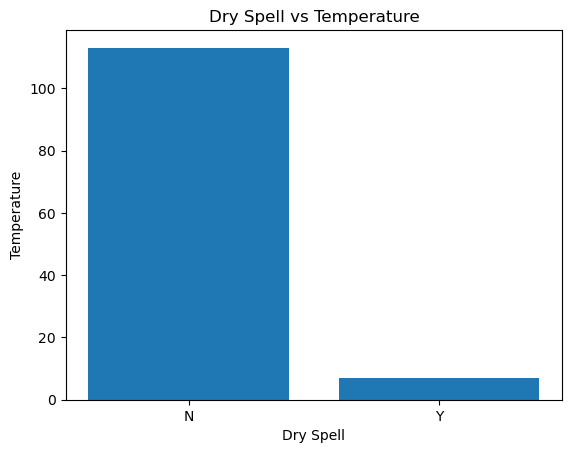

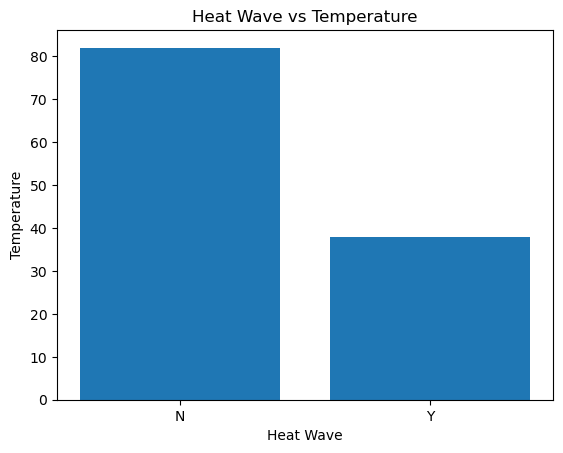

In [22]:
####Dry spell events compared with temperature, rainfall,year and yield

temperature = clean_data['Avg Min Temp °C']
dry_spell = clean_data['Dry Spell']

# Count of Dry Spell events
dry_spell_counts = dry_spell.value_counts()

plt.bar([0, 1], dry_spell_counts, tick_label=['N', 'Y'])
plt.xlabel('Dry Spell')
plt.ylabel('Temperature')
plt.title('Dry Spell vs Temperature')
plt.show()

heat_wave = clean_data['Heat Wave']
#count of heat wave events
heat_wave_counts = heat_wave.value_counts()

plt.bar([0, 1], heat_wave_counts, tick_label=['N', 'Y'])
plt.xlabel('Heat Wave')
plt.ylabel('Temperature')
plt.title('Heat Wave vs Temperature')
plt.show()






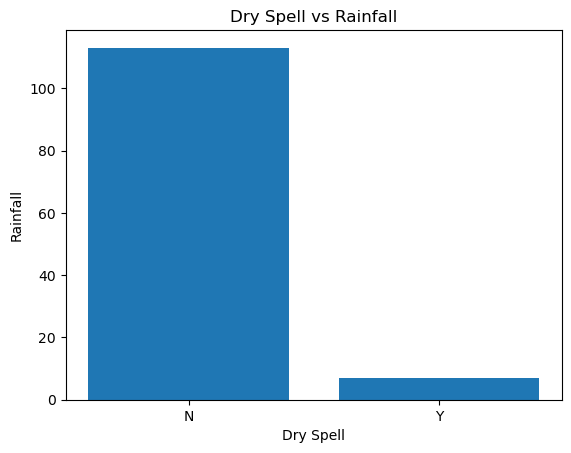

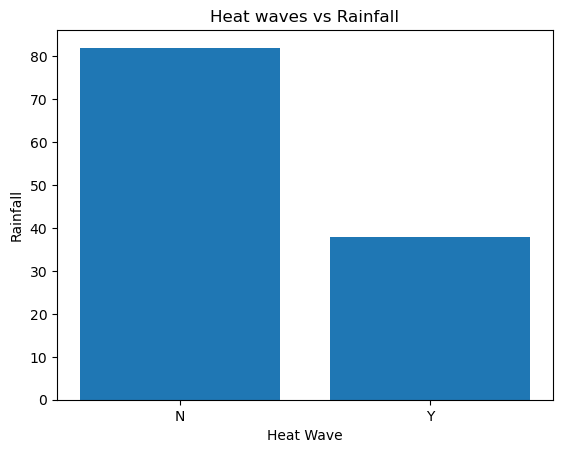

In [23]:
rainfall = clean_data['Yr Rain mm']
dry_spell = clean_data['Dry Spell']

# Count of Dry Spell events
dry_spell_counts = dry_spell.value_counts()

plt.bar([0, 1], dry_spell_counts, tick_label=['N', 'Y'])
plt.xlabel('Dry Spell')
plt.ylabel('Rainfall')
plt.title('Dry Spell vs Rainfall')
plt.show()

heat_wave = clean_data['Heat Wave']
# Count of Dry Spell events
heat_wave_counts = heat_wave.value_counts()

plt.bar([0, 1], heat_wave_counts, tick_label=['N', 'Y'])
plt.xlabel('Heat Wave')
plt.ylabel('Rainfall')
plt.title('Heat waves vs Rainfall')
plt.show()




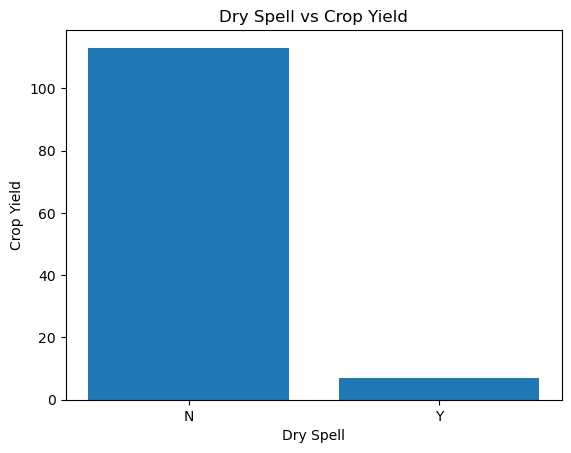

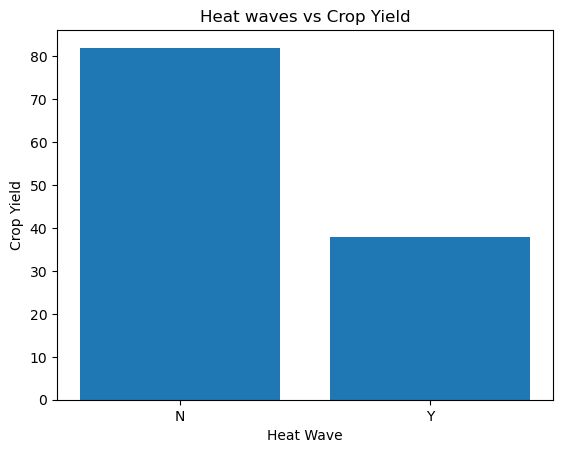

In [24]:
#dry spell vs yield
yield_crop = clean_data['Yield']
dry_spell = clean_data['Dry Spell']
# Count the occurrences of Dry Spell events
dry_spell_counts = dry_spell.value_counts()

plt.bar([0, 1], dry_spell_counts, tick_label=['N', 'Y'])
plt.xlabel('Dry Spell')
plt.ylabel('Crop Yield')
plt.title('Dry Spell vs Crop Yield')
plt.show()

#heat wave vs yield
heat_wave = clean_data['Heat Wave']
# Count the occurrences of Dry Spell events
heat_wave_counts = heat_wave.value_counts()

plt.bar([0, 1], heat_wave_counts, tick_label=['N', 'Y'])
plt.xlabel('Heat Wave')
plt.ylabel('Crop Yield')
plt.title('Heat waves vs Crop Yield')
plt.show()

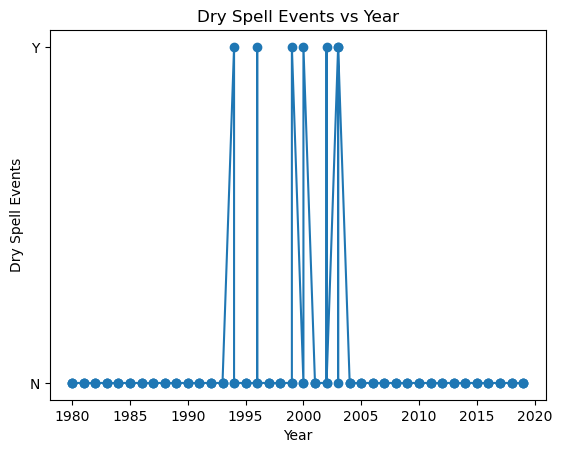

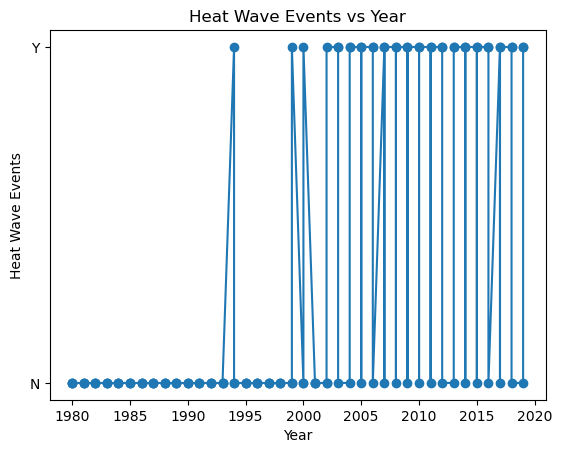

In [25]:
dry_spell_events = clean_data['Dry Spell']
years = clean_data['Year']
# Convert the 'Y' and 'N' values to 1 and 0 for plotting
dry_spell_values = [1 if event == 'Y' else 0 for event in dry_spell_events]

plt.plot(years, dry_spell_values, marker='o')
plt.xlabel('Year')
plt.ylabel('Dry Spell Events')
plt.title('Dry Spell Events vs Year')
plt.yticks([0, 1], ['N', 'Y'])
plt.show()

heat_wave_events = clean_data['Heat Wave']
years = clean_data['Year']
# Convert the 'Y' and 'N' values to 1 and 0 for plotting
heat_wave_values = [1 if event == 'Y' else 0 for event in heat_wave_events]

plt.plot(years, heat_wave_values, marker='o')
plt.xlabel('Year')
plt.ylabel('Heat Wave Events')
plt.title('Heat Wave Events vs Year')
plt.yticks([0, 1], ['N', 'Y'])
plt.show()

### Show appropriate plots of Crop Damage events: Which location has had the most events? Is there a relationship to temperature, rainfall, yield or year?

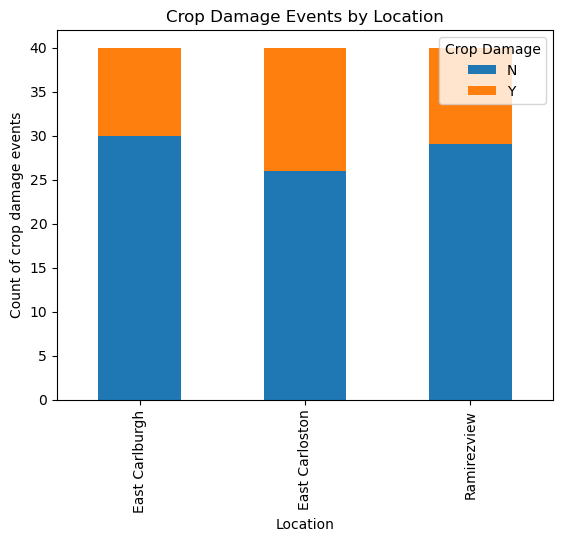

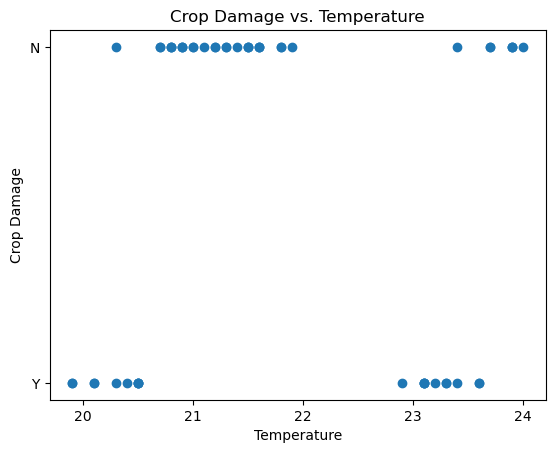

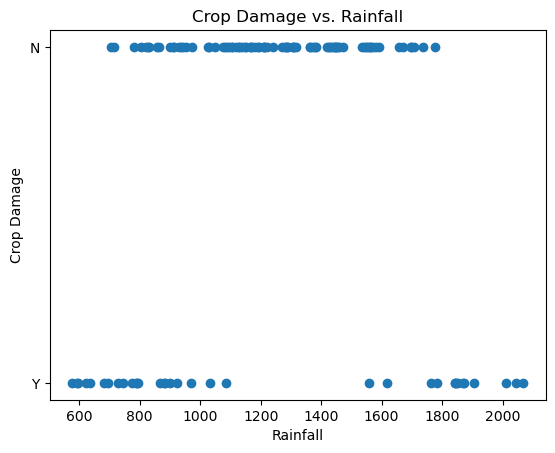

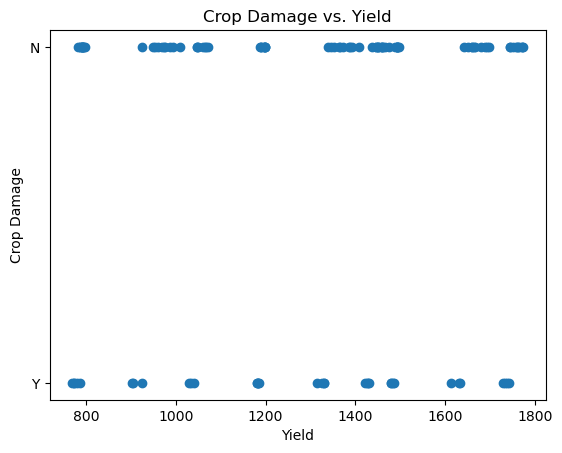

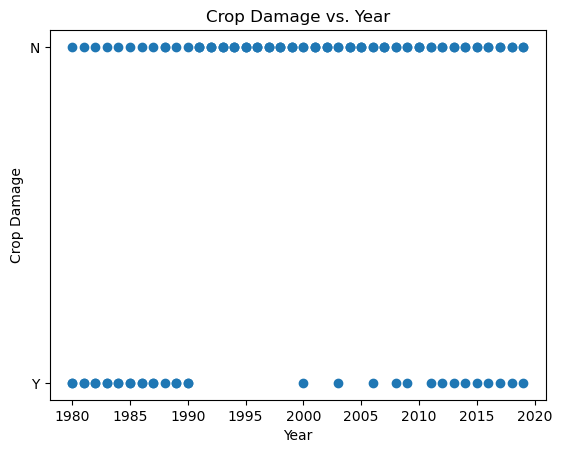

In [26]:
# frequency of crop damage events by location
crop_damage_counts = clean_data.groupby('Location')['Crop Damage'].value_counts().unstack()
# Find the location with the maximum crop damage events
location_most_events = crop_damage_counts.sum().idxmax()

crop_damage_counts.plot(kind='bar', stacked=True)
plt.xlabel('Location')
plt.ylabel('Count of crop damage events')
plt.title('Crop Damage Events by Location')
plt.legend(title='Crop Damage', loc='upper right')
plt.show()

# Scatter plot of crop damage vs. temperature
plt.scatter(clean_data['Avg Min Temp °C'], clean_data['Crop Damage'])
plt.xlabel('Temperature')
plt.ylabel('Crop Damage')
plt.title('Crop Damage vs. Temperature')
plt.show()

# Scatter plot of crop damage vs. rainfall
plt.scatter(clean_data['Yr Rain mm'], clean_data['Crop Damage'])
plt.xlabel('Rainfall')
plt.ylabel('Crop Damage')
plt.title('Crop Damage vs. Rainfall')
plt.show()

# Scatter plot of crop damage vs. yield
plt.scatter(clean_data['Yield'], clean_data['Crop Damage'])
plt.xlabel('Yield')
plt.ylabel('Crop Damage')
plt.title('Crop Damage vs. Yield')
plt.show()

# Scatter plot of crop damage vs. year
plt.scatter(clean_data['Year'], clean_data['Crop Damage'])
plt.xlabel('Year')
plt.ylabel('Crop Damage')
plt.title('Crop Damage vs. Year')
plt.show()

### Is there an observable relationship between rain data and the year: For all locations combined? At each location?

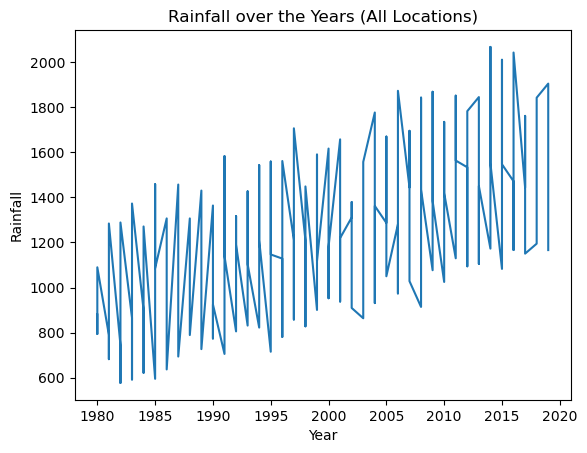

In [27]:
# a Line graph is plotted
plt.plot(clean_data['Year'], clean_data['Yr Rain mm'])
plt.xlabel('Year')
plt.ylabel('Rainfall')
plt.title('Rainfall over the Years (All Locations)')
plt.show()

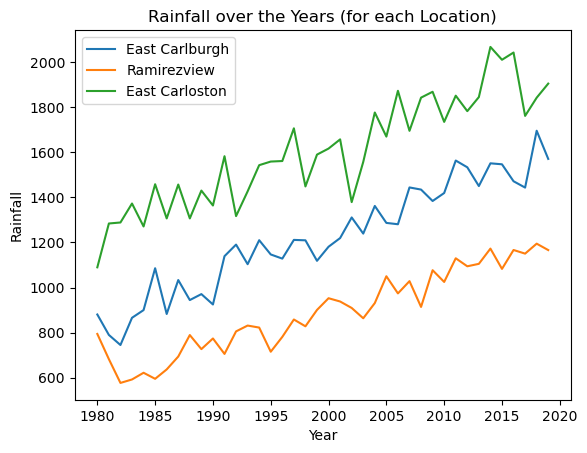

In [28]:
# Get unique locations
locations = clean_data['Location'].unique()

# Plot rain data over the years for each location
for location in locations:
    location_data = clean_data[clean_data['Location'] == location]
    plt.plot(location_data['Year'], location_data['Yr Rain mm'], label=location)

plt.xlabel('Year')
plt.ylabel('Rainfall')
plt.title('Rainfall over the Years (for each Location)')
plt.legend()
plt.show()

### Is there an observable relationship between crop yield and the year? For all locations combined? At each location?

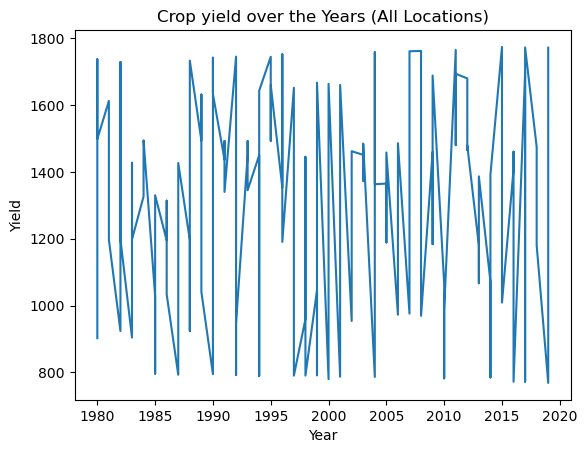

In [29]:
# a Line graph is plotted
plt.plot(clean_data['Year'], clean_data['Yield'])
plt.xlabel('Year')
plt.ylabel('Yield')
plt.title('Crop yield over the Years (All Locations)')
plt.show()

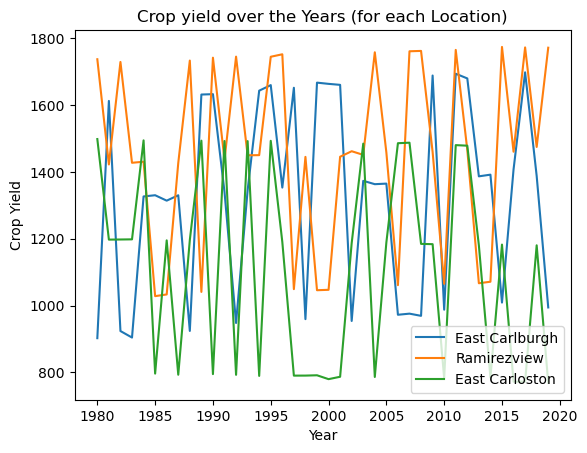

In [30]:
# Get unique locations
locations = clean_data['Location'].unique()

# Plot rain data over the years for each location
for location in locations:
    location_data = clean_data[clean_data['Location'] == location]
    plt.plot(location_data['Year'], location_data['Yield'], label=location)

plt.xlabel('Year')
plt.ylabel('Crop Yield')
plt.title('Crop yield over the Years (for each Location)')
plt.legend()
plt.show()